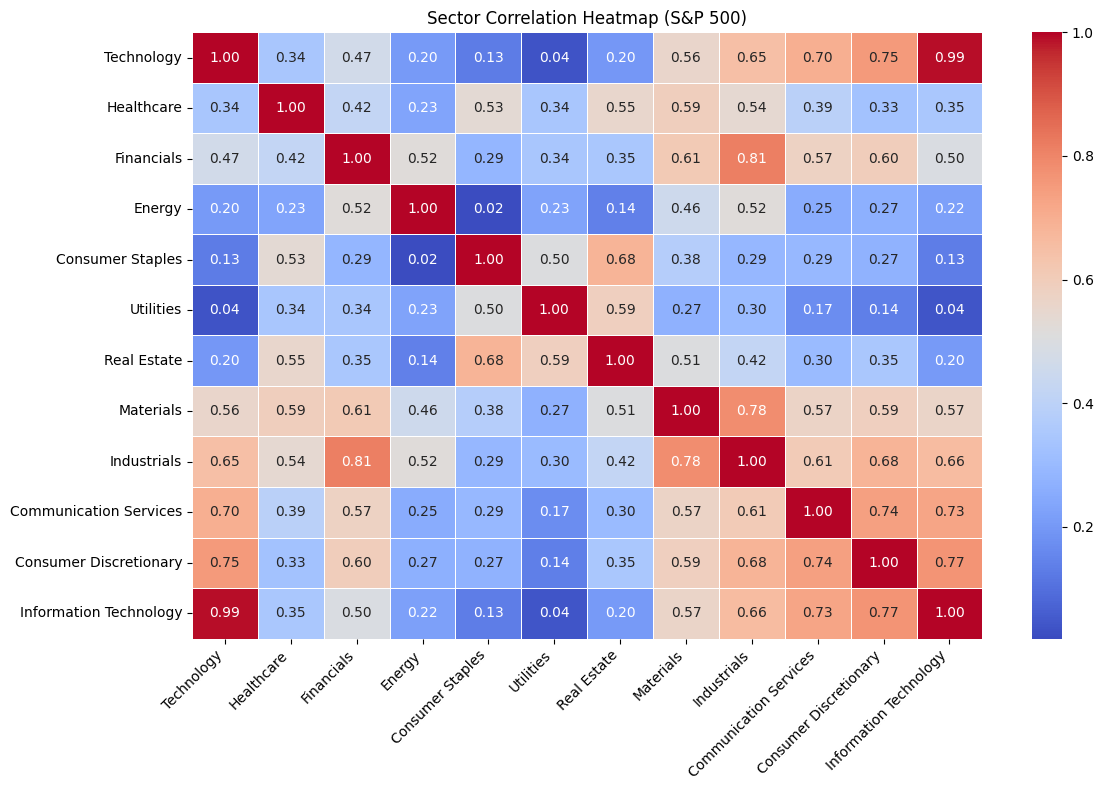

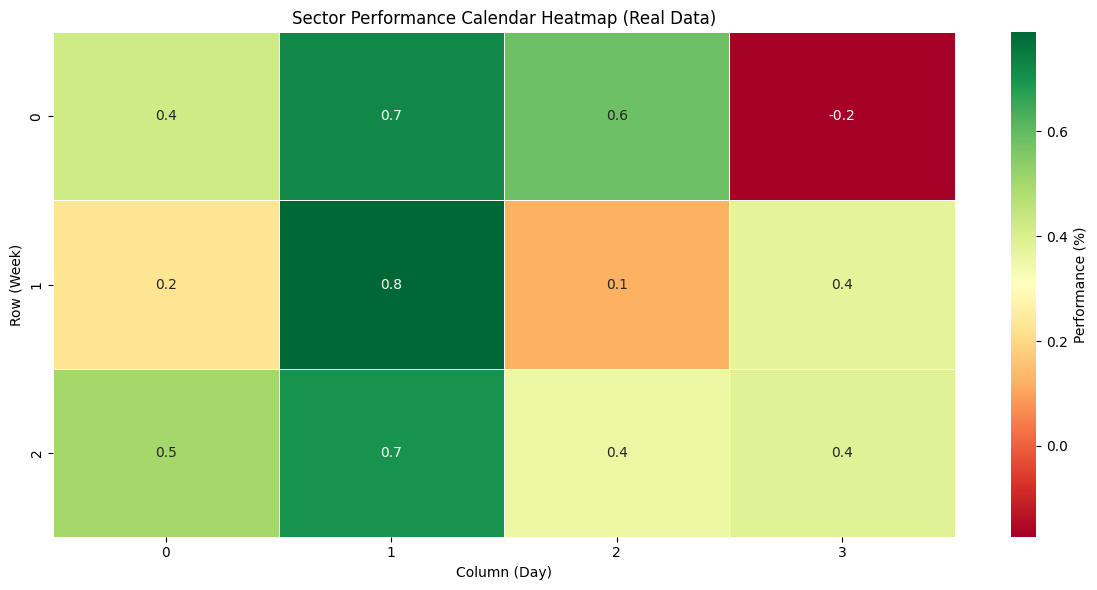

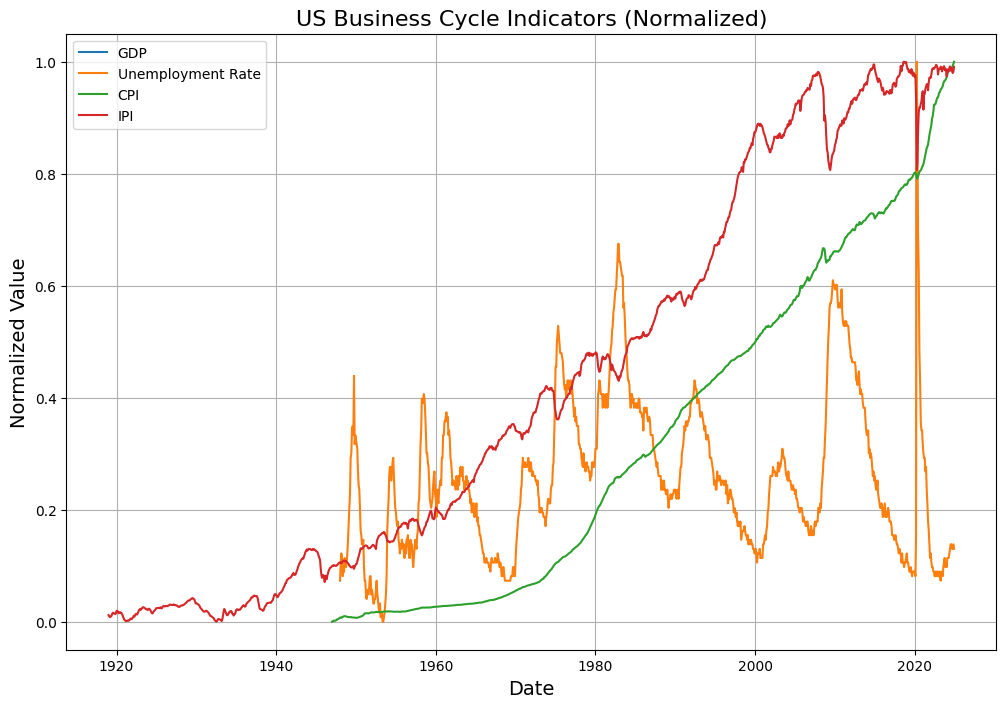

In [7]:
### Segment 1: Sector Correlation Heatmap


# Import necessary libraries
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define sector ETFs
sector_etfs = {
    'Technology': 'XLK',
    'Healthcare': 'XLV',
    'Financials': 'XLF',
    'Energy': 'XLE',
    'Consumer Staples': 'XLP',
    'Utilities': 'XLU',
    'Real Estate': 'XLRE',
    'Materials': 'XLB',
    'Industrials': 'XLI',
    'Communication Services': 'XLC',
    'Consumer Discretionary': 'XLY',
    'Information Technology': 'VGT'
}

# Fetch historical data for all sector ETFs
data = {}
for sector, ticker in sector_etfs.items():
    data[sector] = yf.Ticker(ticker).history(period="6mo")['Close']

# Combine data into a single DataFrame
df = pd.DataFrame(data)

# Calculate daily percentage changes
returns = df.pct_change()

# Compute the correlation matrix
correlation_matrix = returns.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    xticklabels=correlation_matrix.columns,
    yticklabels=correlation_matrix.columns
)

# Customize the plot
plt.title('Sector Correlation Heatmap (S&P 500)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the heatmap
plt.show()

### Explanation
#This segment analyzes the correlation between the daily returns of various sector ETFs over a 6-month period. The correlation matrix is visualized using a heatmap to identify relationships between sectors.



### Segment 2: Sector Performance Heatmap
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define sector ETFs as representatives for 12 sectors
sector_etfs = {
    'Technology': 'XLK',
    'Healthcare': 'XLV',
    'Financials': 'XLF',
    'Energy': 'XLE',
    'Consumer Staples': 'XLP',
    'Utilities': 'XLU',
    'Real Estate': 'XLRE',
    'Materials': 'XLB',
    'Industrials': 'XLI',
    'Communication Services': 'XLC',
    'Consumer Discretionary': 'XLY',
    'Information Technology': 'VGT'  # Alternative technology ETF
}

# Fetch recent performance data (1-day change)
performance = {}
for sector, ticker in sector_etfs.items():
    data = yf.Ticker(ticker).history(period="1d")
    if not data.empty:
        # Calculate percentage change
        close_price = data['Close'].iloc[-1]
        open_price = data['Open'].iloc[-1]
        change = ((close_price - open_price) / open_price) * 100
        performance[sector] = change
    else:
        performance[sector] = None  # Handle cases where data is unavailable

# Convert performance data into a DataFrame
df = pd.DataFrame(list(performance.items()), columns=['Sector', 'Performance (%)'])

# Create a grid-like layout for 12 sectors (calendar-style)
df['Row'] = [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]  # Assign rows (3 rows in a calendar grid)
df['Col'] = [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]  # Assign columns (4 columns in a calendar grid)

# Pivot the data for the heatmap
calendar_data = df.pivot(index='Row', columns='Col', values='Performance (%)')

# Plot the calendar-style heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    calendar_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Performance (%)'}
)

# Customize the plot
plt.title('Sector Performance Calendar Heatmap (Real Data)')
plt.ylabel('Row (Week)')
plt.xlabel('Column (Day)')
plt.tight_layout()

# Show the heatmap
plt.show()



### Explanation
#This segment fetches the daily performance of sector ETFs and visualizes the data using a heatmap. It highlights the intraday performance for a quick overview of sector dynamics.



### Segment 3: US Business Cycle Indicators

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Set up FRED API key (replace with your actual API key)
fred = Fred(api_key='609ee7d12ab5b9668638fbc813fa131b')

# Fetch the latest data from FRED
# Replace 'GDP', 'UNRATE', 'CPIAUCSL', 'INDPRO' with the actual series IDs from FRED
gdp = fred.get_series('GDP')
unemployment_rate = fred.get_series('UNRATE')
cpi = fred.get_series('CPIAUCSL')
ipi = fred.get_series('INDPRO')

# Create a DataFrame for visualization
data = pd.DataFrame({
    'GDP': gdp,
    'Unemployment Rate': unemployment_rate,
    'CPI': cpi,
    'IPI': ipi
})

# Normalize data for comparison
normalized_data = (data - data.min()) / (data.max() - data.min())

# Plot the normalized data
plt.figure(figsize=(12, 8))
for column in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[column], label=column)
plt.title('US Business Cycle Indicators (Normalized)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Normalized Value', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


### Explanation
#This segment uses the FRED API to fetch macroeconomic indicators such as GDP, unemployment rate, CPI, and industrial production index. It normalizes the data for comparison and visualizes the trends over time.


### Segment 4: World GDP Visualization


# Import necessary libraries
import requests
import pandas as pd
import plotly.express as px

# Define the World Bank API endpoint
def fetch_world_bank_data(indicator, date):
    url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator}?date={date}&format=json&per_page=300"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        if len(data) > 1:
            return pd.DataFrame(data[1])
        else:
            print("No data available for the specified indicator and date.")
            return pd.DataFrame()
    else:
        print(f"Failed to fetch data from World Bank API: {response.status_code}")
        return pd.DataFrame()

# Fetch data for a specific indicator and year
indicator = "NY.GDP.PCAP.CD"  # GDP (current US$)
year = "2021"  # Year of interest
data = fetch_world_bank_data(indicator, year)

# Filter and clean the data
if not data.empty:
    data = data[["countryiso3code", "country", "value"]]
    data = data.dropna()  # Remove rows with missing values
    data = data.rename(columns={"countryiso3code": "iso_alpha", "value": "GDP"})
    data["GDP"] = data["GDP"].astype(float)  # Ensure GDP is numeric
    data = data.sort_values(by="GDP", ascending=False)

# Create a choropleth map
if not data.empty:
    fig = px.choropleth(
        data,
        locations="iso_alpha",
        color="GDP",
        hover_name="country",
        color_continuous_scale="Viridis",
        title=f"World Ranking by GDP ({year})",
        labels={"GDP": "GDP (Current US$)"}
    )

    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=False, projection_type="equirectangular"),
        coloraxis_colorbar=dict(title="GDP (US$)")
    )

    fig.show()

### Explanation
#This segment uses the World Bank API to fetch GDP per capita data for all countries and visualizes it on a choropleth map. It provides insights into global economic performance.


In [5]:
!pip install fredapi